In [1]:
!pip install -q transformers datasets sentence-transformers faiss-cpu accelerate bitsandbytes



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 11.4 MB/s eta 0:00:00


In [2]:


from huggingface_hub import notebook_login

# This will displlay a login widget
notebook_login()

In [3]:
from datasets import load_dataset

ds = load_dataset("Threatthriver/Hindi-story-news")

README.md:   0%|          | 0.00/3.00k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


scraped_data (1).json: reconstructing file:   0%|          |  0.00B / 30.3MB            

scraped_data (1).json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4948 [00:00<?, ? examples/s]

In [4]:
from datasets import load_dataset
import pandas as pd

# Set pandas to display the full text in columns
pd.set_option('display.max_colwidth', None)

# 1. Load the dataset from the Hugging Face Hub
try:
  dataset = load_dataset("Threatthriver/Hindi-story-news", split="train")
  print(" Dataset loaded successfully!")
except Exception as e:
  print(f"X Failed to load dataset: {e}")
  # Exit if dataset fails to load
  exit()

# 2. Convert the dataset to a pandas DataFrame for easy viewing
df = dataset.to_pandas()

# 3. Display the first few rows of the DataFrame
print("\n --- First few Rows of the Dataset --- ")
print(df.head(10))

# 4. Display information about the columns and data types
print("\n --- Dataset Info --- ")
df.info()

Repo card metadata block was not found. Setting CardData to empty.


 Dataset loaded successfully!

 --- First few Rows of the Dataset --- 
                                                                                                          title  \
0                                News Video, Hindi News Videos, न्यूज़ वीडियो, हिन्दी समाचार वीडियो - NDTV India   
1                                   NEET Paper Leak BREAKING: NEET पेपर लीक मामले में Ravi Aatri गैंग का भी नाम   
2                     BSP में Akash Anand को फिर से बड़ी ज़िम्मेदारी, BSP के चुनावी प्रचार में फिर दिखेंगे आकाश   
3                                             NEET रद्द होगा या नहीं? जानिए पुराने पेपर लीक केस में क्या हुआ था   
4                       NEET Paper Leak BREAKING: मुख्य आरोपी संजीव मुखिया के घर NDTV, परिवार ने कहा वो निर्दोष   
5                                              NEET Paper Leak Case: EOU ने देवघर से 5 लोगों को हिरासत में लिया   
6  Salman Khan Firing Case: Mumbai Police के हाथ बड़ा सबूत, Forensic Probe में Anmol Bishnoi के आवाज़ की पुष्टि   
7        

In [5]:
# S. Show an example of the content from a single row
print("\n --- Example of a Single Row (Row 2) -- ")
try:
  example_row = df.iloc[2]
  print(f"title: {example_row['title']}")
  print(f"url: {example_row['url']}")
  print(f"\nparagraphs:\n{example_row['paragraphs']}")
except IndexError:
  print("Dataset has fewer than 3 rows.")


 --- Example of a Single Row (Row 2) -- 
title: BSP में Akash Anand को फिर से बड़ी ज़िम्मेदारी, BSP के चुनावी प्रचार में फिर दिखेंगे आकाश
url: https://ndtv.in/videos/akash-anand-will-again-get-a-big-responsibility-in-bsp-akash-will-be-seen-again-in-bsp-s-election-ca-806260

paragraphs:
['Akash Anand BSP:\xa0आकाश आनंद चुनाव प्रचार के दौरान अपने भाषणों के लिए काफी चर्चा में थे. इसे उनके राजनीतिक करियर के लिए एक झटके के रूप में देखा जा रहा था. लेकिन अब बहुजन समाज पार्टी (BSP) में आकाश आनंद को फिर से बड़ी ज़िम्मेदारी\xa0सौंपी\xa0जा रही है']


In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Set device for GPU acceleration if available
device = "cuda" if torch. cuda. is_available() else "cpu"
print(f" Using device: {device}")

# Define the model name and quantization configuration
model_name = "Qwen/Qwen1.5-1.8B-Chat"

# for smaller models, we don't need Quantization
quantization_config = BitsAndBytesConfig(
  load_in_4bit=True,
  bnb_4bit_quant_type="nf4",
  bnb_4bit_compute_dtype=torch.bfloat16
)

print(f"\n Loading Hindi LLM: {model_name}")

# Load the tokenizer and the quantized model
hf_token = "your_huggingface_token"
tokenizer = AutoTokenizer. from_pretrained(model_name, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    #quantization_config=quantization_config,
    device_map="auto",
    token=hf_token
)
model.eval() # Set the model to evaluation mode

print("Hindi LLM is ready.")

 Using device: cuda

 Loading Hindi LLM: Qwen/Qwen1.5-1.8B-Chat


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.67GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

Hindi LLM is ready.


In [12]:
from typing import List, Dict

# 1. Define the device (already defined in your loading script)
# This ensures PyTorch operations are sent to the GPU if available.
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Define the Hindi RAG Prompt Template
# This template instructs the LLM on how to behave. It's written in Hindi
# to ensure the best possible response from the language model.
HINDI_RAG_PROMPT_TEMPLATE = """
निर्देश: निम्नलिखित संदर्भ का उपयोग करके प्रश्न का उत्तर दें। आपका उत्तर केवल दिए गए संदर्भ पर आधारित होना चाहिए। यदि उत्तर संदर्भ में नहीं है, तो कहें कि 'जानका

संदर्भ:
-----
{context}
---------
g: {question}

उत्तर:
"""
# 3. Define the LLM Generation Function
# This function takes the formatted prompt, sends it to your loaded Qwen model,
# and returns the generated text.
def generate_hindi_llm_response(prompt: str) -> str:
  """
  Generates a response using the pre-loaded Qwen-1.5-1.8B-Chat model.
  """
# Qwen-Chat models work best with the chat template format.
# We create a message list to send to the tokenizer.
  messages = [
  {"role": "system", "content": "आप एक सहायक एआई हैं जो केवल दिए गए संदर्भ के आधार पर हिंदी में उत्तर देते हैं।"},
  {"role": "user", "content": prompt}

]

# Apply the chat template to format the input correctly
# This returns a BatchEncoding object, so we need to extract the 'input_ids' tensor
  encoded_input = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
        ).to(device) # Move the input to the GPU

  input_ids_tensor = encoded_input['input_ids'] # Extract the actual input_ids tensor

# Generate the output tokens from the model
  outputs = model.generate(
      input_ids_tensor, # Pass the actual input_ids tensor
      max_new_tokens=500,
      do_sample=True,
      temperature=0.7,
      top_p=0.9
)



# Decode the generated tokens into a string, skipping the prompt part
# Use the shape of the actual input_ids tensor for slicing
  response_tokens = outputs[0][input_ids_tensor.shape[-1]:]
  response = tokenizer.decode(response_tokens, skip_special_tokens=True)

  return response

Hindi retriever

In [8]:
import faiss
import numpy as np
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from typing import List, Dict

# (Ensure your LLM model, tokenizer, device, and HINDI_RAG_PROMPT_TEMPLATE are loaded/defined above)

class HindiRetriever:
    """
    Retrieves relevant passages from the Hindi Dataset.
    """
    def __init__(self, embedding_model_name: str = 'paraphrase-multilingual-MiniLM-L12-v2', dataset_name: str = "Threatthriver/Hindi-story-news"):
        # Load the multilingual model to create text embeddings
        self.embedding_model = SentenceTransformer(embedding_model_name, device=device)
        print(f"\nLoading and processing data from '{dataset_name}' ... ")

        # Load, chunk, and filter the dataset
        self.chunks = self._load_and_chunk_data(dataset_name)

        print("Creating vector index from the articles ... ")
        # Create the searchable vector index
        self.index = self._create_faiss_index()
        print("Hindi Retriever is ready.")

    def _load_and_chunk_data(self, dataset_name: str) -> List[str]:
        # Load the specified dataset
        dataset = load_dataset(dataset_name, split="train")
        chunks = []
        for item in dataset:
            # Check if the column exists and is a list
            if 'paragraphs' in item and isinstance(item['paragraphs'], list):
                chunks.extend(item['paragraphs'])

        # Filter out very short chunks to ensure quality
        return [chunk.strip() for chunk in chunks if len(chunk.strip()) > 50]

    def _create_faiss_index(self):
        # Convert all text chunks into vector embeddings
        embeddings = self.embedding_model.encode(self.chunks, show_progress_bar=True)
        embedding_dim = embeddings.shape[1]

        # Create a FAISS index for fast search
        index = faiss.IndexFlatL2(embedding_dim)
        index.add(np.array(embeddings).astype('float32'))
        return index

    def retrieve(self, query: str, k: int = 5) -> List[str]:
        # Convert the Hindi query into a vector
        query_embedding = self.embedding_model.encode([query])

        # Search the index for the top 'k' most similar passages
        _, indices = self.index.search(np.array(query_embedding).astype('float32'), k)
        return [self.chunks[i] for i in indices[0]]


def answer_in_hindi(query: str, retriever: HindiRetriever) -> str:
    """
    The main RAG pipeline function for Hindi.
    """
    print(f"\nQuery: {query}")

    # 1. RETRIEVE: Find relevant Hindi passages
    retrieved_passages = retriever.retrieve(query, k=5)
    context = "\n\n --- \n\n".join(retrieved_passages)

    print("*" * 100)
    print("Context is: \n", context)
    print("*" * 100)

    # 2. AUGMENT: Create the prompt with the retrieved context
    prompt = HINDI_RAG_PROMPT_TEMPLATE.format(context=context, question=query)

    # 3. GENERATE: Get the final answer from the Hindi LLM
    final_answer = generate_hindi_llm_response(prompt)

    # Clean the output to only show the answer part if "उत्तर:" or similar markers exist
    if "उत्तर:" in final_answer:
        final_answer = final_answer.split("उत्तर:")[-1].strip()

    return final_answer

In [9]:
retriver= HindiRetriever()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...


Loading and processing data from 'Threatthriver/Hindi-story-news' ... 


Repo card metadata block was not found. Setting CardData to empty.


Creating vector index from the articles ... 


Batches:   0%|          | 0/1681 [00:00<?, ?it/s]

Hindi Retriever is ready.


In [15]:
# Question from Row 1
question_1 = "Tell me about भर्ती परीक्षा about different jobs."  # "NEET पेपर?"
answer_1 = answer_in_hindi(question_1, retriver)
print(f"\n 3t:\n{answer_1}")

print("\n" + "="*50)



Query: Tell me about भर्ती परीक्षा about different jobs.
****************************************************************************************************
Context is: 
 जॉब (वेबसाइट में) के लिए:हमारे साथ काम करना चाहते हैं तो देर किस बात की। कवर लेटर के साथ अपनी सीवी यहां भेजें: jobs@expressindia.com

 --- 

BPSC Assistant Professor Recruitment 2024: बिहार लोक सेवा आयोग (BPSC) ने नई भर्ती का नोटिफिकेशन जारी किया है. बीपीएससी ने असिस्टेंट प्रोफेसर के 1339 पदों को भरने के लिए योग्य उम्मीदवारों से आवेदन आमंत्रित किए हैं. ये भर्तियां राज्य चिकित्सा महाविद्यालय एवं अस्पतालों के विभिन्न विभागों (विशेषता) के लिए हैं. इच्छुक और योग्य उम्मीदवार बीपीएससी भर्ती 2024 के लिए आयोग की आधिकारिक वेबसाइट bpsc.bih.nic.in से आवेदन कर सकते हैं. हालांकि आवेदन की प्रक्रिया अभी शुरू नहीं हुई है. बीपीएससी असिस्टेंट प्रोफेसर की भर्ती के लिए ऑनलाइन आवेदन फॉर्म 25 जून से भरे जाएंगे. उम्मीदवार 26 जुलाई 2024 तक आवेदन कर सकते हैं. इस भर्ती अभियान के जरिए असिस्टेंट प्रोफेसर के कुल 1339 पदों को भरा जाएगा.

 --- 



In [14]:
# Question from Row 2
question_2 = "Who is getting बड़ी ज़िम्मेदारी?"
answer_2 = answer_in_hindi(question_2, retriver)
print(f"\n: 3t:\n{answer_2}")

print("\n" + "="*50)


Query: Who is getting बड़ी ज़िम्मेदारी?
****************************************************************************************************
Context is: 
 जिसमें सबके कोई न कोई अपनी मर्ज़ी से लिए गए दायित्व थे

 --- 

समाजिक उत्तरदायित्व आदर्श-भेद से अर्थ-भेद का व्यंजक पाया जाता है।

 --- 

अच्छा व्यवहार और सहायता के लिए तत्पर होना, यानी, आदमी को उस रेंज पर लाना है जहाँ से उस पर अचूक निशाना लगाया जा सके।

 --- 

जो जितना ज़्यादा लोगों का जितना ज़्यादा नुक़सान कर सके

 --- 

kisi ko kutubminar se chillakar kahne ki zarurat nahin hai
****************************************************************************************************

: 3t:
The question "Who is getting the bigger jīmārādi?" asks about the person who receives a larger jīmārādi, which is a type of reward or prize given to someone for their achievements. The context of this question is related to Indian culture and society, specifically regarding the concept of "jīmārādi" in rural India.
In Indian traditional societies, jīmār

### Sentiment Analysis of Paragraphs

In [25]:
from transformers import pipeline

# Load a multilingual sentiment analysis pipeline
# This model provides a 5-star rating for sentiment.
sentiment_pipeline = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=0 if torch.cuda.is_available() else -1)

print("New sentiment analysis pipeline loaded (nlptown/bert-base-multilingual-uncased-sentiment).")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

New sentiment analysis pipeline loaded (nlptown/bert-base-multilingual-uncased-sentiment).


In [32]:
# Helper function to extract sentiment for a list of paragraphs
def get_sentiment_for_paragraphs(paragraphs_list):
    # Ensure paragraphs_list is treated as a list for length check
    if len(paragraphs_list) == 0: # Use len() instead of 'not' for robustness
        return []

    # The sentiment pipeline can take a list of strings
    # We'll take the first paragraph for simplicity or join them.
    # For accurate analysis, each paragraph should ideally be analyzed individually.
    # For this demonstration, we'll analyze the first paragraph of each entry.
    first_paragraphs = [p[0] if isinstance(p, list) and p else '' for p in paragraphs_list]

    # Filter out empty strings for analysis
    non_empty_paragraphs = [p for p in first_paragraphs if p.strip() != '']

    if not non_empty_paragraphs:
        return [{'label': 'NEUTRAL', 'score': 1.0}] * len(paragraphs_list)

    results = sentiment_pipeline(non_empty_paragraphs)

    # Map results back to original list length, filling with neutral for empty ones
    full_results = []
    result_idx = 0
    for p in first_paragraphs:
        if p.strip() != '':
            full_results.append(results[result_idx])
            result_idx += 1
        else:
            full_results.append({'label': 'NEUTRAL', 'score': 1.0})

    return full_results


# Apply sentiment analysis to the 'paragraphs' column
# We'll apply it to a small sample due to potential computation time for the full dataset
sample_df = df.head(100).copy() # Take a sample for demonstration
sample_df['sentiment_raw'] = sample_df['paragraphs'].apply(get_sentiment_for_paragraphs)

# Extract label and score for better readability (taking the sentiment of the first paragraph)
sample_df['sentiment_label'] = sample_df['sentiment_raw'].apply(lambda x: x[0]['label'] if x else 'UNKNOWN')
sample_df['sentiment_score'] = sample_df['sentiment_raw'].apply(lambda x: x[0]['score'] if x else 0.0)

print("Sentiment analysis applied to a sample of paragraphs.")
display(sample_df[['title', 'paragraphs', 'sentiment_label', 'sentiment_score']])

Sentiment analysis applied to a sample of paragraphs.


title  \
0                             News Video, Hindi News Videos, न्यूज़ वीडियो, हिन्दी समाचार वीडियो - NDTV India   
1                                NEET Paper Leak BREAKING: NEET पेपर लीक मामले में Ravi Aatri गैंग का भी नाम   
2                  BSP में Akash Anand को फिर से बड़ी ज़िम्मेदारी, BSP के चुनावी प्रचार में फिर दिखेंगे आकाश   
3                                          NEET रद्द होगा या नहीं? जानिए पुराने पेपर लीक केस में क्या हुआ था   
4                    NEET Paper Leak BREAKING: मुख्य आरोपी संजीव मुखिया के घर NDTV, परिवार ने कहा वो निर्दोष   
..                                                                                                       ...   
95                          Anrich Arno Nortje: Latest News, Photos, Videos on Anrich Arno Nortje - NDTV.COM   
96                            Dale Willem Steyn: Latest News, Photos, Videos on Dale Willem Steyn - NDTV.COM   
97                  Icc T20 World Cup 2024: Latest News, Photos, Videos on Icc T20 World Cup 2024 - NDTV.COM   
98                                                Cricket: Latest News, Photos, Videos on Cricket - NDTV.COM   
99  टी20 वर्ल्ड कप सट्टेबाजी : मध्य प्रदेश में बड़े रैकेट का भंडाफोड़, डॉलर, पाउंड और दिरहम में होता था सौदा   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

/tmp/ipykernel_721/4171293598.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sentiment_label', y='count', data=sentiment_counts, palette='viridis')


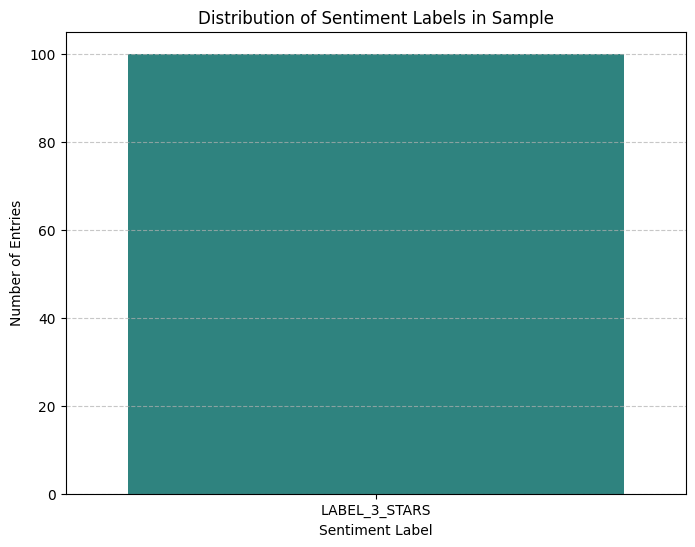

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts of sentiment labels
sentiment_counts = sample_df['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment_label', 'count']

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='sentiment_label', y='count', data=sentiment_counts, palette='viridis')
plt.title('Distribution of Sentiment Labels in Sample (New Model)')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Entries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()